In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import rioxarray as rxr
import rasterio as rio
from shapely.geometry import Point, LineString, Polygon
from scipy.io import loadmat

# plotting
import matplotlib.pyplot as plt

## Data needs
Import anything that I might use for this sandbox

In [2]:
tuolumneBasin = gpd.read_file('/scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/shapefiles/catchment/Tuolumne_River_lumped_HRUs_GRUs.shp')
yosemiteSites = pd.read_csv('/scratch/dlhogan/ess-project-data/geospatial-data/yosemite_hydroclimate_location_data.csv')
tuolumneDEM = rxr.open_rasterio('/scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/attributes/elevation/dem/domain_Tuolumne_River_lumped_elv.tif')
forcingDEM = gpd.read_file('/scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/shapefiles/forcing/forcing_ERA5.shp')

In [3]:
cols = ['Station Abbreviation', 'Station Name',
       'Station Type','Station Status',
       'Station Operator', 'Elevation (ft)', 'Established Date',
       'Meteorological Station Type', 'x', 'y'
        ]
yosemiteSites = yosemiteSites[cols]

# convert elevation to meters
yosemiteSites['elev_m'] = yosemiteSites['Elevation (ft)'] * 0.3048

In [16]:
# up to 2023 data
tuolumneGauge_rawDataPath = "/scratch/dlhogan/ess-project-data/streamflow-data/TuolumneRiver/Tuolumne_4streams_until2023.mat"
tuolumneGauge_qcDataPath = "/scratch/dlhogan/ess-project-data/streamflow-data/TuolumneRiver/TuolumneStreamflow_2002_2021/data/"

## Sand Castle 1 - Plotting up locations of gauges

In [17]:
# create a geometry column for the gauges
yosemiteSites['geometry'] = yosemiteSites.apply(lambda row: Point(row['x'], row['y'], row['elev_m']), axis=1)

yosemiteSites = gpd.GeoDataFrame(yosemiteSites, geometry='geometry', crs='EPSG:4326')

In [18]:
# constrain to just Tuolumne sites using the tuolumneBasin boundary to crop 
tuolumneGauges = yosemiteSites[(yosemiteSites.within(tuolumneBasin.union_all()) & (yosemiteSites['Station Type'] == 'Stream Gage'))].copy()
# get approximate elevations from DEM
tuolumneGauges['dem_elev'] = tuolumneGauges.geometry.apply(lambda point: tuolumneDEM.sel(x=point.x, y=point.y, method='nearest').values[0])

In [19]:
# clip DEM to basin and fill no data with nan
tuolumneDEM_clipped = tuolumneDEM.rio.clip(tuolumneBasin.geometry, tuolumneBasin.crs, drop=True).where(tuolumneDEM != tuolumneDEM.rio.nodata)
tuolumneDEM_clipped = tuolumneDEM_clipped.where(tuolumneDEM_clipped != tuolumneDEM_clipped.rio.nodata, np.nan).squeeze()

In [20]:
# create elevation bands based on gauge elevations
elv_above_120 = tuolumneDEM_clipped.where((tuolumneDEM_clipped > tuolumneGauges[tuolumneGauges['Station Abbreviation'] == 'Tuolumne@120']['dem_elev'].squeeze()))

elv_below_120 = tuolumneDEM_clipped.where((tuolumneDEM_clipped < tuolumneGauges[tuolumneGauges['Station Abbreviation'] == 'Tuolumne@120']['dem_elev'].squeeze()) &
                                            (tuolumneDEM_clipped >= 0))
elv_between_120_and_lyell = tuolumneDEM_clipped.where((tuolumneDEM_clipped >= tuolumneGauges[tuolumneGauges['Station Abbreviation'] == 'Tuolumne@120']['dem_elev'].squeeze()) & 
                                              (tuolumneDEM_clipped < tuolumneGauges[tuolumneGauges['Station Abbreviation'] == 'LyellBlwMaclure']['dem_elev'].squeeze()))
elv_above_lyell = tuolumneDEM_clipped.where(tuolumneDEM_clipped >= tuolumneGauges[tuolumneGauges['Station Abbreviation'] == 'LyellBlwMaclure']['dem_elev'].squeeze())

# convert to masks
mask_below_120 = elv_below_120.where(elv_below_120.notnull(), np.nan).where(elv_below_120.isnull(), 1)
mask_between_120_and_lyell = elv_between_120_and_lyell.where(elv_between_120_and_lyell.notnull(), np.nan).where(elv_between_120_and_lyell.isnull(), 1)
mask_above_lyell = elv_above_lyell.where(elv_above_lyell.notnull(), np.nan).where(elv_above_lyell.isnull(), 1)

In [21]:
# get total bounds of the elv_120 
bounds_120 = elv_below_120.where(elv_below_120.notnull(), np.nan).where(elv_below_120.isnull(), 1).rio.bounds()
print(bounds_120)

(-119.66041666666666, 37.739583333333336, -119.19958333333334, 38.11375)


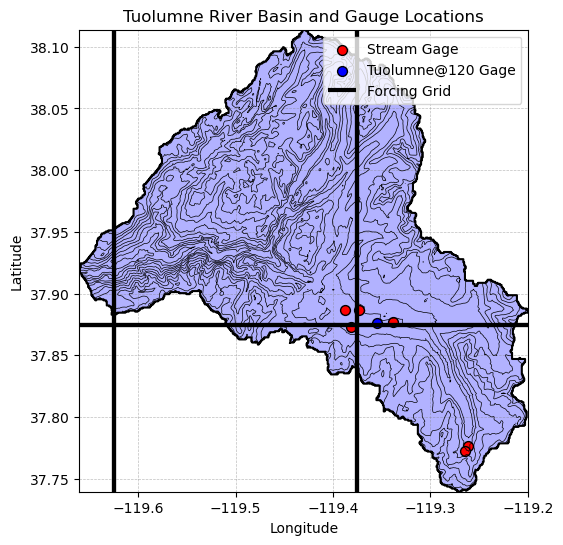

In [22]:
# plot the basin and gauge locations
fig, ax = plt.subplots(figsize=(6, 6))
tuolumneBasin.plot(ax=ax, color='blue', alpha=0.3)
tuolumneBasin.boundary.plot(ax=ax, color='black')

# add the DEM as a background
# tuolumneDEM.plot(ax=ax, cmap='terrain', alpha=0.25)
# plot DEM as contours
cl = ax.contour(
    tuolumneDEM_clipped.x, tuolumneDEM_clipped.y, tuolumneDEM_clipped.values,
    levels=20, colors="k", linewidths=0.5
)
# plot mask outlines
# mask_below_120.plot(ax=ax, add_colorbar=False, alpha=0.5, cmap='Blues',)
# mask_between_120_and_lyell.plot(ax=ax, add_colorbar=False, alpha=0.3, cmap='Greens',)
# mask_above_lyell.plot(ax=ax, add_colorbar=False, alpha=0.3, cmap='Reds',)
tuolumneGauges[~(tuolumneGauges['Station Abbreviation'] == 'Tuolumne@120')].plot(ax=ax, color='red', markersize=50, ec='black', label='Stream Gage')
tuolumneGauges[(tuolumneGauges['Station Abbreviation'] == 'Tuolumne@120')].plot(ax=ax, color='blue', markersize=50, ec='black', label='Tuolumne@120 Gage')

# plot forcing boundaries
forcingDEM.boundary.plot(ax=ax, color='black', lw=3, label='Forcing Grid')
# plot elevation masks 
ax.set_title('Tuolumne River Basin and Gauge Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
# crop to boundary of tuolumne basin
ax.set_xlim(tuolumneBasin.total_bounds[0], tuolumneBasin.total_bounds[2])
ax.set_ylim(tuolumneBasin.total_bounds[1], tuolumneBasin.total_bounds[3])
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5, color='gray')
ax.legend()

# Sand Castle 2 - Gathering Tuolumne streamflow

## Part 1: Cleaning data through 2023
Issues I still have are:
1. No time step or datetime associated with observations
2. No location information.

In [23]:
# Replace 'your_file.mat' with the actual path to your .mat file
keys_to_exclude = ['__function_workspace__', 'None']
try:
    mat_data = loadmat(tuolumneGauge_rawDataPath)

    # save first three keys and their data as metadata
    metadata = {}
    for key in list(mat_data.keys())[:3]:
        metadata[key] = mat_data[key]
        # pop it from the dictionary
        mat_data.pop(key)
    for key in keys_to_exclude:
        if key in mat_data:
            mat_data.pop(key)
    print("Metadata keys:", metadata.keys())
    print("Data keys:", mat_data.keys())
    
except FileNotFoundError:
    print(f"Error: The file '{tuolumneGauge_rawDataPath.split('/')[-1]}' was not found.")
except Exception as e:
    print(f"An error occurred: {e}")

Metadata keys: dict_keys(['__header__', '__version__', '__globals__'])
Data keys: dict_keys(['adjusted_stagecm', 'adjusted_stagecm1', 'adjusted_stagecm2', 'adjusted_stagecm3', 'barocorrected_pressurecm', 'barocorrected_pressurecm1', 'barocorrected_pressurecm2', 'barocorrected_pressurecm3', 'discharge_flag', 'discharge_flag1', 'discharge_flag2', 'discharge_flag3', 'estimated_dischargecms', 'estimated_dischargecms1', 'estimated_dischargecms2', 'estimated_dischargecms3', 'raw_pressurecm', 'raw_pressurecm1', 'raw_pressurecm2', 'raw_pressurecm3', 'water_temperaturedeg_C', 'water_temperaturedeg_C1', 'water_temperaturedeg_C2', 'water_temperaturedeg_C3'])


/home/dlhogan/miniforge3/envs/data-and-plotting/lib/python3.13/site-packages/scipy/io/matlab/_mio.py:235: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Considerscipy.io.matlab.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


In [24]:
def get_gauge_data(gauge_dict, gauge_number):
    subset = {}
    # get all keys that end with the gauge number
    for key in gauge_dict.keys():
        # if the key does not end with a number, 
        if (not key[-1].isdigit()) & (gauge_number == 0):
            subset[key] = gauge_dict[key]
        elif key.endswith(str(gauge_number)):
            subset[key] = gauge_dict[key]
    return subset

def format_column_names(column_template, chars_to_drop):
    new_columns = [col.replace("_", " ").title() for col in column_template]
    for i, col in enumerate(new_columns):
        for char in chars_to_drop:
            if col.endswith(char):
                col = col.replace(char, "").strip()
        new_columns[i] = col
    new_columns = [col.title().replace(" ", "_") for col in new_columns]
    return new_columns

def filter_invalid_discharge(df, col="Estimated_Discharge", min_thresh=0, max_thresh=250, max_diff=30, drop_flagged=True):
    # Replace negative discharge values with NaN
    df[col] = df[col].apply(lambda x: np.nan if x < min_thresh else x)
    # Replace discharge values above the maximum threshold with NaN
    df[col] = df[col].apply(lambda x: np.nan if x > max_thresh else x)
    # Replace discharge values with NaN if the difference between consecutive values exceeds max_diff
    df[col] = df[col].where(df[col].diff().abs() <= max_diff, np.nan)
    # replace discharge values with Nan if "Discharge_Flag" is not 0
    if ("Discharge_Flag" in df.columns) & (not drop_flagged):
        df.loc[df["Discharge_Flag"] != 0, col] = np.nan
    return df

In [25]:
# convert to dataframe for easier viewing, keys are columns, values are rows
gauge0 = get_gauge_data(mat_data, 0)
gauge1 = get_gauge_data(mat_data, 1)
gauge2 = get_gauge_data(mat_data, 2)
gauge3 = get_gauge_data(mat_data, 3)

In [26]:
# convert from dict to dataframe
gauge0_df = pd.DataFrame({key: value.squeeze() for key, value in gauge0.items()})
gauge1_df = pd.DataFrame({key: value.squeeze() for key, value in gauge1.items()})
gauge2_df = pd.DataFrame({key: value.squeeze() for key, value in gauge2.items()})
gauge3_df = pd.DataFrame({key: value.squeeze() for key, value in gauge3.items()})
# rename columns to be more descriptive
column_template = ['adjusted_stagecm', 'barocorrected_pressurecm', 'discharge_flag',
       'estimated_dischargecms', 'raw_pressurecm', 'water_temperaturedeg_C']
# correct columns 
chars_to_drop = ["cm", "cms", "deg C"]

gauge0_df.columns = format_column_names(column_template, chars_to_drop)
gauge1_df.columns = format_column_names(column_template, chars_to_drop)
gauge2_df.columns = format_column_names(column_template, chars_to_drop)
gauge3_df.columns = format_column_names(column_template, chars_to_drop)

# filter invalid discharge values
tuolumneAt120_noqc_df = filter_invalid_discharge(gauge0_df, min_thresh=0, max_thresh=125, drop_flagged=False)
lyellBlwMaclure_noqc_df = filter_invalid_discharge(gauge1_df, min_thresh=0, max_thresh=15, max_diff=2, drop_flagged=False)
lyellAbvTB_noqc_df = filter_invalid_discharge(gauge2_df, min_thresh=0, max_thresh=60, drop_flagged=False)
danaFkBugCamp_noqc_df = filter_invalid_discharge(gauge3_df, min_thresh=0, max_thresh=125, drop_flagged=False)

Tuolumne@120 (no QC) - Estimated Discharge stats:
Mean: 4.92 cms
Min: 0.00 cms
Max: 61.22 cms
Std: 7.94 cms

LyellBlwMaclure (no QC) - Estimated Discharge stats:
Mean: 0.73 cms
Min: 0.00 cms
Max: 11.61 cms
Std: 1.06 cms

LyellAbvTB (no QC) - Estimated Discharge stats:
Mean: 3.50 cms
Min: 0.00 cms
Max: 59.29 cms
Std: 5.87 cms

DanaFkBugCamp (no QC) - Estimated Discharge stats:
Mean: 1.80 cms
Min: 0.00 cms
Max: 58.98 cms
Std: 3.72 cms



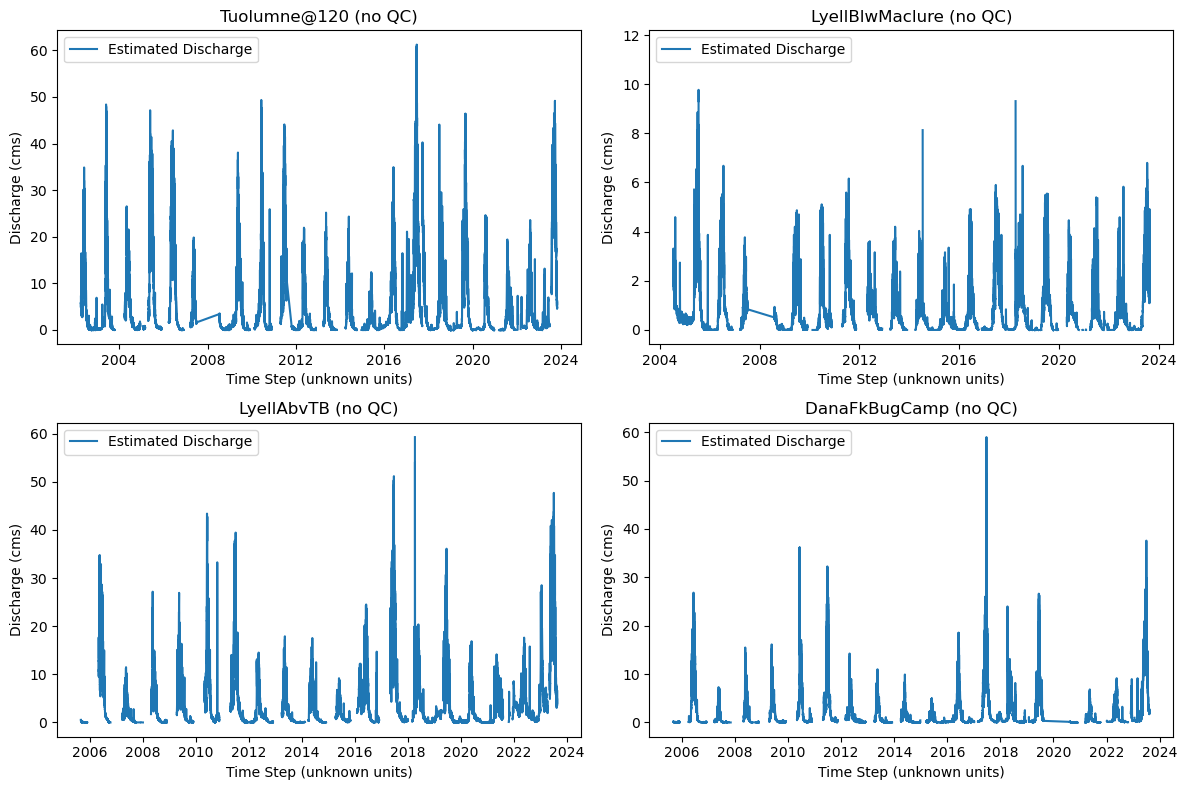

In [58]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax = ax.flatten()
gauge_dfs = [tuolumneAt120_noqc_df, lyellBlwMaclure_noqc_df, lyellAbvTB_noqc_df, danaFkBugCamp_noqc_df]
gauge_names = ['Tuolumne@120 (no QC)', 'LyellBlwMaclure (no QC)', 'LyellAbvTB (no QC)', 'DanaFkBugCamp (no QC)']
for i, (gauge_df, gauge_name) in enumerate(zip(gauge_dfs, gauge_names)):
    print(f"{gauge_name} - Estimated Discharge stats:"
          f"\nMean: {gauge_df['Estimated_Discharge'].mean():.2f} cms"
          f"\nMin: {gauge_df['Estimated_Discharge'].min():.2f} cms"
          f"\nMax: {gauge_df['Estimated_Discharge'].max():.2f} cms"
          f"\nStd: {gauge_df['Estimated_Discharge'].std():.2f} cms\n")
    ax[i].plot(gauge_df['Estimated_Discharge'], label='Estimated Discharge')
    ax[i].set_title(gauge_name)
    ax[i].set_xlabel('Time Step (unknown units)')
    ax[i].set_ylabel('Discharge (cms)')
    ax[i].legend()
plt.tight_layout()

In [59]:
# print the longest gauge record
print(f"Gauge 0 record length: {len(gauge0_df)}")
print(f"Gauge 1 record length: {len(gauge1_df)}")
print(f"Gauge 2 record length: {len(gauge2_df)}")
print(f"Gauge 3 record length: {len(gauge3_df)}")

Gauge 0 record length: 349306
Gauge 1 record length: 315901
Gauge 2 record length: 313329
Gauge 3 record length: 301964


## Part 2: Loading QCed data

In [30]:
danaFkBugCamp_df = pd.read_csv(tuolumneGauge_qcDataPath + 'DanaFkBugCamp_streamflow.csv', skiprows=9, parse_dates=['DateTime'],index_col='DateTime')
lyellAbvTB_df = pd.read_csv(tuolumneGauge_qcDataPath + 'LyellAbvTB_streamflow.csv', skiprows=9, parse_dates=['DateTime'],index_col='DateTime')
lyellBlwMaclure_df = pd.read_csv(tuolumneGauge_qcDataPath + 'LyellBlwMaclure_streamflow.csv', skiprows=9, parse_dates=['DateTime'],index_col='DateTime')
tuolumneAt120_df = pd.read_csv(tuolumneGauge_qcDataPath + 'Tuolumne120_streamflow.csv', skiprows=9, parse_dates=['DateTime'],index_col='DateTime')

In [62]:
# infer_objects copy=False-9999 values
danaFkBugCamp_df = danaFkBugCamp_df.replace(-9999, np.nan)
danaFkBugCamp_df = danaFkBugCamp_df.infer_objects(copy=False)

lyellAbvTB_df = lyellAbvTB_df.replace(-9999, np.nan)
lyellAbvTB_df = lyellAbvTB_df.infer_objects(copy=False)

lyellBlwMaclure_df = lyellBlwMaclure_df.replace(-9999, np.nan)
lyellBlwMaclure_df = lyellBlwMaclure_df.infer_objects(copy=False)

tuolumneAt120_df = tuolumneAt120_df.replace(-9999, np.nan)
tuolumneAt120_df = tuolumneAt120_df.infer_objects(copy=False)

# convert Estimated Discharge from cfs to cms
convert_to_cms = False
for gauge in [tuolumneAt120_df, lyellBlwMaclure_df, lyellAbvTB_df, danaFkBugCamp_df]:
    if convert_to_cms:
        gauge["Estimated_Discharge"] = gauge["Estimated_Discharge"] * 0.0283168
# filter using the same filters as above
tuolumneAt120_df = filter_invalid_discharge(tuolumneAt120_df, min_thresh=0, max_thresh=125, drop_flagged=False)
lyellBlwMaclure_df = filter_invalid_discharge(lyellBlwMaclure_df, min_thresh=0, max_thresh=15, max_diff=2, drop_flagged=False)
lyellAbvTB_df = filter_invalid_discharge(lyellAbvTB_df, min_thresh=0, max_thresh=60, drop_flagged=False)
danaFkBugCamp_df = filter_invalid_discharge(danaFkBugCamp_df, min_thresh=0, max_thresh=125, drop_flagged=False)


In [63]:
for gauge in [tuolumneAt120_df, lyellBlwMaclure_df, lyellAbvTB_df, danaFkBugCamp_df]:
    print("Estimated_Discharge - stats:"
          f"\nMean: {gauge["Estimated_Discharge"].mean():.2f} cms"
          f"\nMin: {gauge["Estimated_Discharge"].min():.2f} cms"
          f"\nMax: {gauge["Estimated_Discharge"].max():.2f} cms"
          f"\nStd: {gauge["Estimated_Discharge"].std():.2f} cms\n")

Estimated_Discharge - stats:
Mean: 4.23 cms
Min: 0.00 cms
Max: 61.22 cms
Std: 7.40 cms

Estimated_Discharge - stats:
Mean: 0.68 cms
Min: 0.00 cms
Max: 11.61 cms
Std: 1.03 cms

Estimated_Discharge - stats:
Mean: 3.10 cms
Min: 0.00 cms
Max: 59.29 cms
Std: 5.38 cms

Estimated_Discharge - stats:
Mean: 1.69 cms
Min: 0.00 cms
Max: 58.98 cms
Std: 3.56 cms



In [64]:
noqc_gauge_dfs = [tuolumneAt120_noqc_df, lyellBlwMaclure_noqc_df, lyellAbvTB_noqc_df, danaFkBugCamp_noqc_df]
qc_gauge_dfs = [tuolumneAt120_df, lyellBlwMaclure_df, lyellAbvTB_df, danaFkBugCamp_df]

### WARNING: This assumes no missing time-steps between the end of the QCed data and the start of the non-QCed data!!!
for gauge_noqc, gauge_qc in zip(noqc_gauge_dfs, qc_gauge_dfs):
    # get the first gauge_qc length indeces
    qc_indeces = gauge_qc.index
    new_index = pd.date_range(start=qc_indeces[-1], periods=len(gauge_noqc[len(gauge_qc)-1:]), freq='30min')
    # combine the indeces
    combined_index = qc_indeces.union(new_index)
    # print the start and end of the combined index
    print(f"Combined index start: {combined_index[0]}, end: {combined_index[-1]}")
    # print(f"Combined index length: {len(combined_index)}, QC length: {len(gauge_qc)}, No QC length: {len(gauge_noqc)}")
    gauge_noqc.index = combined_index
    # set unreasonable discharge values in the no QC data to NaN
    gauge_noqc = filter_invalid_discharge(gauge_noqc, min_thresh=0, max_thresh=200, drop_flagged=False)

Combined index start: 2001-10-30 19:59:00, end: 2023-10-30 23:30:00
Combined index start: 2004-07-16 00:00:00, end: 2023-08-23 18:00:00
Combined index start: 2005-09-03 01:00:00, end: 2023-08-17 21:00:00
Combined index start: 2005-09-01 22:00:00, end: 2023-08-16 21:00:00


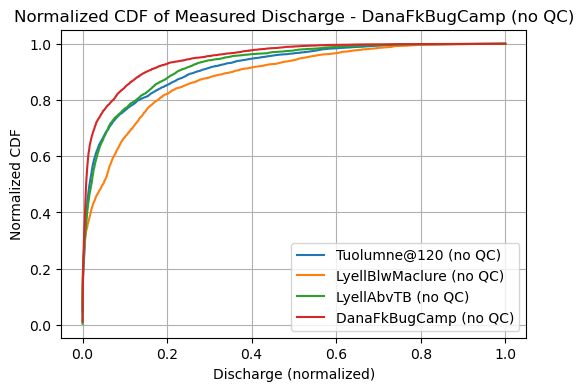

In [93]:
# calculate the normalized CDFs of the discharge at each gauge
fig, ax = plt.subplots(figsize=(6, 4))
for gauge_qc, gauge_name in zip(qc_gauge_dfs, gauge_names):
    combined_discharge = gauge_qc['Estimated_Discharge'].resample('D').mean().sort_values()
    # normalized discharge 
    normalized_discharge = combined_discharge / combined_discharge.max()
    cdf = combined_discharge.rank(method='average') / len(combined_discharge.dropna())
    ax.plot(normalized_discharge, cdf, label=gauge_name)
    ax.set_xlabel('Discharge (normalized)')
    ax.set_ylabel('Normalized CDF')
    ax.set_title(f'Normalized CDF of Measured Discharge - {gauge_name}')
    ax.grid(True)
    ax.legend()

In [109]:
# create a correlation heatmap between the gauges using qc_gauge_dfs
import seaborn as sns
merge1 = pd.merge(qc_gauge_dfs[0]['Estimated_Discharge'], qc_gauge_dfs[1]['Estimated_Discharge'], left_index=True, right_index=True, how='outer', suffixes=('_T120', '_LBM'))
merge2 = pd.merge(qc_gauge_dfs[2]['Estimated_Discharge'], qc_gauge_dfs[3]['Estimated_Discharge'], left_index=True, right_index=True, how='outer', suffixes=('_LABvTB', '_DFkBC'))
qc_combined_df = pd.merge(merge1, merge2, left_index=True, right_index=True, how='outer')
qc_combined_df.columns = ['Estimated_Discharge_T120', 'Estimated_Discharge_LBM', 'Estimated_Discharge_LABvTB', 'Estimated_Discharge_DFkBC']
# resample to daily mean
qc_combined_df = qc_combined_df.resample('D').mean()

In [113]:
hetch_hetchy_reconstructed_df = pd.read_csv("/scratch/dlhogan/ess-project-data/streamflow-data/TuolumneRiver/TuolumneRiver_streamflow_1970_2015.csv", index_col=0, parse_dates=True)
hetch_hetchy_reconstructed_df = hetch_hetchy_reconstructed_df.rename(columns={"discharge": "Estimated_Discharge_HH"})
# fill the range to match that of the other gauges
hh_index = pd.date_range(start=qc_combined_df.index[0], end=qc_gauge_dfs[0].index[-1], freq='D')
hetch_hetchy_reconstructed_df = hetch_hetchy_reconstructed_df.reindex(hh_index)
qc_combined_df = pd.merge(qc_combined_df, hetch_hetchy_reconstructed_df['Estimated_Discharge_HH'], left_index=True, right_index=True, how='outer')

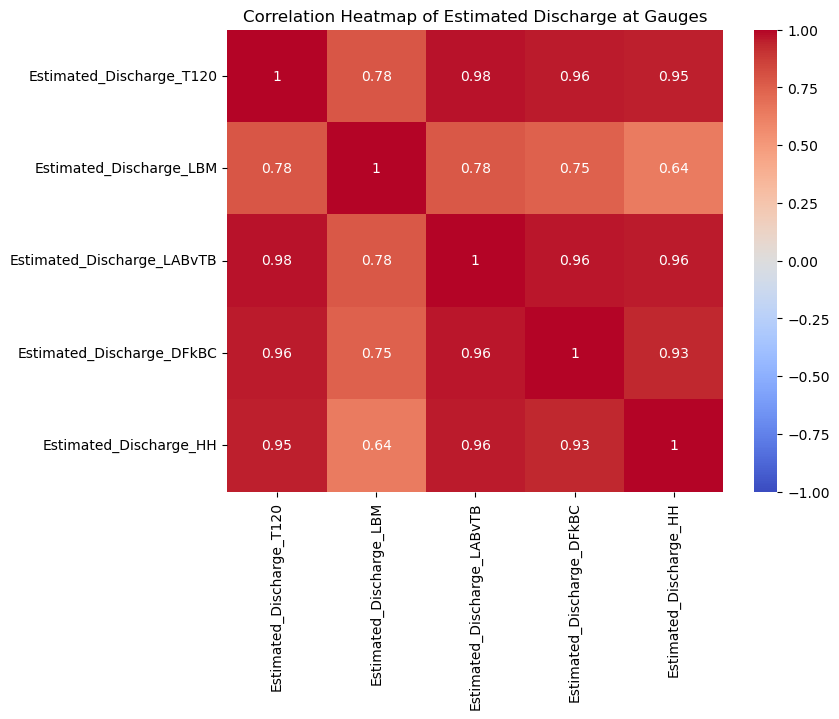

In [114]:

discharge_cols = [col for col in qc_combined_df.columns if 'Estimated_Discharge' in col]
corr_matrix = qc_combined_df.resample('D').mean().corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Estimated Discharge at Gauges')
plt.show()

In [158]:
gauge_qc

DateTime
2001-10-30    1.28
2001-10-31    1.36
2001-11-01    1.39
2001-11-02    1.25
2001-11-03    1.44
              ... 
2021-08-08     NaN
2021-08-09     NaN
2021-08-10     NaN
2021-08-11     NaN
2021-08-12     NaN
Freq: D, Name: Estimated_Discharge_HH, Length: 7227, dtype: float64

ValueError: 'x' has size 7227, but 'y1' has an unequal size of 365

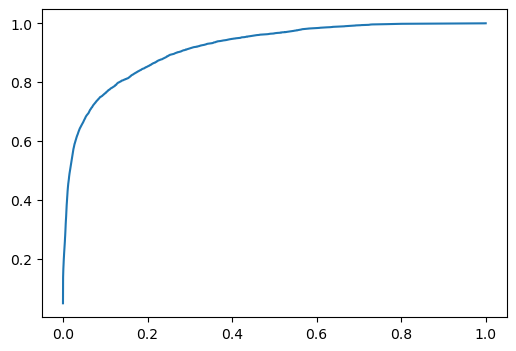

In [ ]:
# calculate the normalized CDFs of the discharge at each gauge
fig, ax = plt.subplots(figsize=(6, 4))
for gauge_name in qc_combined_df.columns:
    gauge_qc = qc_combined_df[gauge_name]
    combined_discharge = gauge_qc.sort_values()
    # normalized discharge 
    normalized_discharge = combined_discharge / combined_discharge.max()
    cdf = combined_discharge.rank(method='average') / len(combined_discharge.dropna())
    ax.plot(normalized_discharge, cdf, label=gauge_name)

    # shade the cds for years 2011 and 2015, which was extremely high and low years
    # 2011 cdf
    normalized_2011 = gauge_qc.loc['2010-10-01': '2011-09-30'].sort_values() / gauge_qc.loc['2010-10-01': '2011-09-30'].max()
    cdf_2011 = gauge_qc.loc['2010-10-01': '2011-09-30'].sort_values().rank(method='average') / len(gauge_qc.loc['2010-10-01': '2011-09-30'].dropna())
    # 2015 cdf
    normalized_2015 = gauge_qc.loc['2014-10-01': '2015-09-30'].sort_values() / gauge_qc.loc['2014-10-01': '2015-09-30'].max()
    cdf_2015 = gauge_qc.loc['2014-10-01': '2015-09-30'].sort_values().rank(method='average') / len(gauge_qc.loc['2014-10-01': '2015-09-30'].dropna())
    ax.fill_between(normalized_2011, cdf_2011, cdf_2015, 
                 alpha=0.3, color='gray', label='Difference between years')

    ax.set_xlabel('Discharge (normalized)')
    ax.set_ylabel('Normalized CDF')
    ax.set_title(f'Normalized CDF of Measured Discharge - {gauge_name}')
    ax.grid(True)
    ax.legend()


In [150]:
annual_flow[missing_counts.max(axis=1) < 200]

/tmp/ipykernel_1716076/2836100658.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  annual_flow[missing_counts.max(axis=1) < 200]


,Estimated_Discharge_T120,Estimated_Discharge_LBM,Estimated_Discharge_LABvTB,Estimated_Discharge_DFkBC,Estimated_Discharge_HH
DateTime,,,,,
2001,0.000000,0.000000,0.000000,0.000000,377.42
2009,1355.020833,208.257500,791.870904,371.281840,10935.46
2010,1437.871174,205.513360,990.285417,560.331345,13439.75
2011,1440.868393,271.849792,1383.220453,775.193736,17910.20
2012,731.915929,142.700000,496.294424,305.446374,5878.93
2013,707.180811,141.787917,506.544242,236.243413,6235.72
2014,627.850639,133.360936,469.387310,205.854138,4983.31
2015,437.212292,110.703373,298.404534,123.625208,3601.66


In [154]:
annual_flow = qc_combined_df.groupby(qc_combined_df.index.year).sum()
missing_counts = qc_combined_df.isna().groupby(qc_combined_df.index.year).sum()
# drop yers when any gauge is missing more than 200 days 
annual_flow = annual_flow.loc[2002:][missing_counts.max(axis=1) < 200]
for col in annual_flow.columns:
    # get max year
    max_year = annual_flow[col].idxmax()
    min_year = annual_flow[col].idxmin()
    print(f"{col} - Max annual flow: {annual_flow[col].max()} in {max_year}")
    print(f"{col} - Min annual flow: {annual_flow[col].min()} in {min_year}")

Estimated_Discharge_T120 - Max annual flow: 1440.868392857143 in 2011
Estimated_Discharge_T120 - Min annual flow: 437.21229166666666 in 2015
Estimated_Discharge_LBM - Max annual flow: 271.84979166666665 in 2011
Estimated_Discharge_LBM - Min annual flow: 110.70337322695036 in 2015
Estimated_Discharge_LABvTB - Max annual flow: 1383.2204528985508 in 2011
Estimated_Discharge_LABvTB - Min annual flow: 298.4045336879433 in 2015
Estimated_Discharge_DFkBC - Max annual flow: 775.1937361111111 in 2011
Estimated_Discharge_DFkBC - Min annual flow: 123.62520833333333 in 2015
Estimated_Discharge_HH - Max annual flow: 17910.2 in 2011
Estimated_Discharge_HH - Min annual flow: 3601.66 in 2015


/tmp/ipykernel_1716076/3405532498.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  annual_flow = annual_flow.loc[2002:][missing_counts.max(axis=1) < 200]


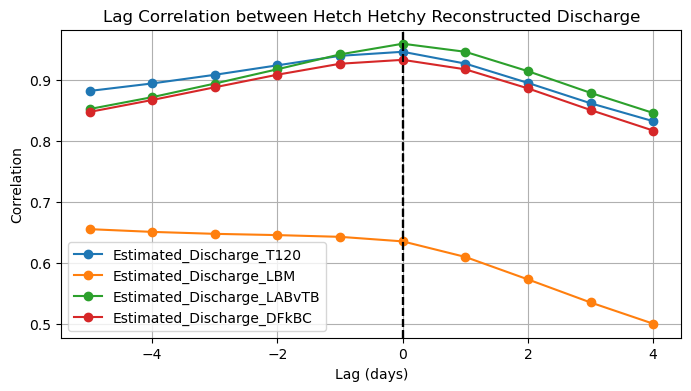

In [130]:
# calculate daily lag-correlations between HH reconstructed discharge and the other gauges
hh_discharge = qc_combined_df['Estimated_Discharge_HH']
fig, ax = plt.subplots(figsize=(8, 4))
for col in discharge_cols:
    if col == 'Estimated_Discharge_HH':
        continue
    gauge_discharge = qc_combined_df[col]
    # calculate lag correlation for lags between -30 and 30 days
    lags = range(-5, 5)
    correlations = [hh_discharge.corr(gauge_discharge.shift(lag)) for lag in lags]
    ax.plot(lags, correlations, marker='o', label=col)
    ax.set_title(f'Lag Correlation between Hetch Hetchy Reconstructed Discharge')
    ax.set_xlabel('Lag (days)')
    ax.set_ylabel('Correlation')
    ax.grid(True)
    ax.axvline(0, color='black', linestyle='--')
    ax.legend()

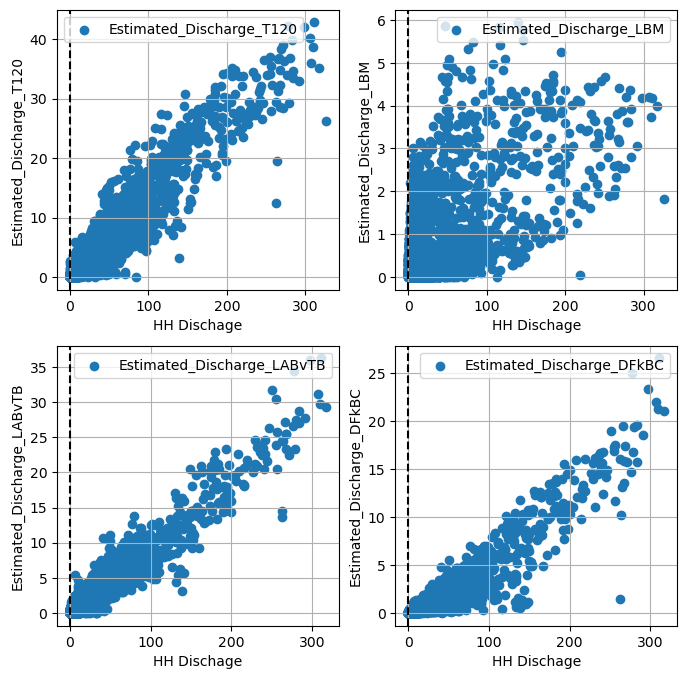

In [139]:
# calculate daily lag-correlations between HH reconstructed discharge and the other gauges
hh_discharge = qc_combined_df['Estimated_Discharge_HH']
fig, axs = plt.subplots(2,2, figsize=(8, 8))
axs = axs.flatten()
for icol, col in enumerate(discharge_cols):
    if col == 'Estimated_Discharge_HH':
        continue
    gauge_discharge = qc_combined_df[col]
    # calculate lag correlation for lags between -30 and 30 days
    ax = axs[icol]
    ax.scatter(hh_discharge, gauge_discharge, marker='o', label=col)
    ax.set_xlabel('HH Dischage')
    ax.set_ylabel(col)
    ax.grid(True)
    ax.axvline(0, color='black', linestyle='--')
    ax.legend()

K-S test between HH and Estimated_Discharge_T120: statistic=0.4171, p-value=0.0000
K-S test between HH and Estimated_Discharge_LBM: statistic=0.6736, p-value=0.0000
K-S test between HH and Estimated_Discharge_LABvTB: statistic=0.4365, p-value=0.0000
K-S test between HH and Estimated_Discharge_DFkBC: statistic=0.6096, p-value=0.0000


Text(0, 0.5, 'Density')

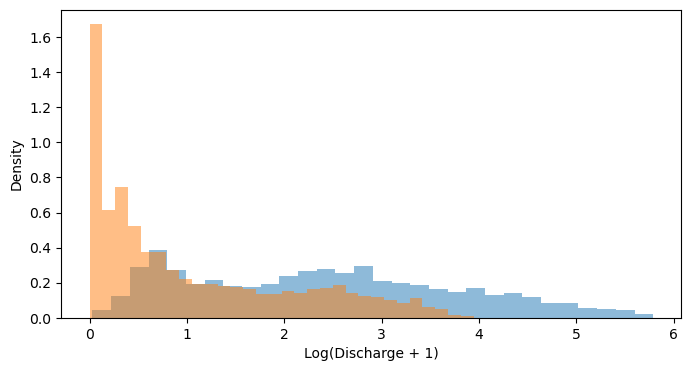

In [137]:
# use log-scaled statistical test to compare hh_discharge and gauge_discharge
# convert to lognormal distribution
from scipy.stats import lognorm, kstest
hh_discharge_log = np.log(hh_discharge.dropna() + 1)
for col in discharge_cols:
    if col == 'Estimated_Discharge_HH':
        continue
    gauge_discharge = qc_combined_df[col]
    gauge_discharge_log = np.log(gauge_discharge.dropna() + 1)
    # perform kstest
    stat, p_value = kstest(hh_discharge_log, gauge_discharge_log)
    print(f'K-S test between HH and {col}: statistic={stat:.4f}, p-value={p_value:.4f}')

# plot histograms of the log-transformed discharge values for HH and one of the gauges
col = 'Estimated_Discharge_T120'
gauge_discharge = qc_combined_df[col]
gauge_discharge_log = np.log(gauge_discharge.dropna() + 1)
plt.figure(figsize=(8, 4))
plt.hist(hh_discharge_log, bins=30, alpha=0.5, label='HH Discharge (log)', density=True)
plt.hist(gauge_discharge_log, bins=30, alpha=0.5, label=f'{col} Discharge (log)', density=True)
plt.xlabel('Log(Discharge + 1)')
plt.ylabel('Density')

In [259]:
# save each non-QCed dataframe to csv
for gauge, name in zip(noqc_gauge_dfs, ['TuolumneAt120', 'LyellBlwMaclure', 'LyellAbvTB', 'DanaFkBugCamp']):
    gauge.to_csv(tuolumneGauge_qcDataPath + f'{name}_streamflow_until2023_noQC.csv', index_label='DateTime')

# Plot layers in SUMMA